In [116]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

In [117]:
# loading True dataset
true_df = pd.read_csv("True.csv")
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [118]:
# loading Fake datatset
fake_df = pd.read_csv("Fake.csv")
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [119]:
print(true_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
None


In [120]:
print(fake_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None


In [121]:
# creating a label of '1' for True Datatset (News)
true_df['label'] = 1

In [122]:
# creating a lable of '0' for False/Fake Dataset (News)
fake_df['label'] = 0

In [123]:
true_df.head(5)

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [124]:
fake_df.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [125]:
# now concatenating two csv files.
news = pd.concat((fake_df,true_df),axis=0)

In [126]:
news.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [127]:
news.tail(5)

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [128]:
# checking for null values in the dataset
news.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [129]:
# drop columns (not required)
news = news.drop(['title','subject','date'],axis=1)

In [130]:
news.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


Now, we can see that top part of the datatset contains fake news and bottom part contains true/real news. Our model will be biased. So, reshuffle is required.

In [131]:
# sampling or reshuffling
news = news.sample(frac=1)

In [132]:
# checking the datatset after reshuffling
news.head()

,text,label
14645,ANKARA (Reuters) - Political infighting among ...,1
19903,***WARNING***This video is GRAPHIC!***,0
16809,If I found out my college-age daughter was att...,0
11406,Maddow has a freak out at the 48 second mark:,0
16620,DUBLIN (Reuters) - Irish student Ibrahim Halaw...,1


In [133]:
# reset index
news.reset_index(inplace=True)

In [134]:
news.head()

,index,text,label
0,14645,ANKARA (Reuters) - Political infighting among ...,1
1,19903,***WARNING***This video is GRAPHIC!***,0
2,16809,If I found out my college-age daughter was att...,0
3,11406,Maddow has a freak out at the 48 second mark:,0
4,16620,DUBLIN (Reuters) - Irish student Ibrahim Halaw...,1


In [135]:
news.drop(['index'],axis=1,inplace=True)

In [136]:
news.head()

,text,label
0,ANKARA (Reuters) - Political infighting among ...,1
1,***WARNING***This video is GRAPHIC!***,0
2,If I found out my college-age daughter was att...,0
3,Maddow has a freak out at the 48 second mark:,0
4,DUBLIN (Reuters) - Irish student Ibrahim Halaw...,1


In [137]:
# checking what's in the text.
print(news['text'][1])

***WARNING***This video is GRAPHIC!***


In [138]:
def preprocess(text):
  # convert into lowercase
  text = text.lower()

  # remove URLs
  url_pattern = r'https?://\S+|www\.\S+'
  text = re.sub(url_pattern, '', text)

  # remove html tags
  html_pattern = r'<[^>]+>'
  text = re.sub(html_pattern, '', text)

  # remove punctuations
  punctuation_pattern = r'[!"#$%&\'()*+,-./:;<=>?@\[\\\]^_`{|}~]'
  text = re.sub(punctuation_pattern, '', text)

  # remove digits
  digit_pattern = r'\d+'
  text = re.sub(digit_pattern, '', text)

  # remove newline characters
  newline_pattern = r'[\n\r]+'
  text = re.sub(newline_pattern, ' ', text)

  return text

In [139]:
# now applying the function to news['text']
news['text'] = news['text'].apply(preprocess)

In [140]:
print(news['text'][1])

warningthis video is graphic


In [141]:
# defining X and y
X = news['text']
y = news['label']

In [142]:
print(X.shape)

(44898,)


In [143]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [144]:
# shape of X_train
print(X_train.shape)

(31428,)


In [145]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [146]:
# Using Tfidfvectorizer
# converting into numericals

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [147]:
# Using Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr = LogisticRegression()

In [148]:
lr.fit(X_train,y_train)

LogisticRegression()

In [149]:
pred_lr = lr.predict(X_test)

In [150]:
lr.score(X_test,y_test)

0.9867112100965107

In [151]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7034
           1       0.98      0.99      0.99      6436

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



In [152]:
# checking the training and testing accuracy for Linear Regression
train_acc = lr.score(X_train, y_train)
test_acc  = lr.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 0.9908
Test accuracy:  0.9867


Linear SVM (LinearSVC) usually performs well on sparse TF-IDF text data. It optimizes for the margin between classes rather than probability calibration.

In [153]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

# evaluate
train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print()
print(classification_report(y_test, pred_svm))

Train accuracy: 0.9995
Test accuracy:  0.9949

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7034
           1       0.99      0.99      0.99      6436

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



In [154]:
def predict_news(text, model=svm):
    # apply the SAME preprocessing used during training
    cleaned = preprocess(text)
    # vectorize using the SAME fitted vectorizer (don't fit again!)
    vectorized = vectorizer.transform([cleaned])

    # predict
    pred = model.predict(vectorized)[0]
    label = "REAL" if pred == 1 else "FAKE"

    # confidence score (SVM uses decision_function, not predict_proba)
    if hasattr(model, "predict_proba"):
        confidence = model.predict_proba(vectorized)[0].max()
    else:
        score = model.decision_function(vectorized)[0]
        confidence = abs(score)  # distance from the decision boundary

    print(f"Text: {text[:100]}...")
    print(f"Prediction: {label}")
    print(f"Confidence/margin: {confidence:.3f}")
    print()
    return label

In [155]:
# a plausible REAL news story
real_example = """
The Federal Reserve raised interest rates by a quarter point on Wednesday,
citing persistent inflation pressures in the housing and services sectors.
Chair Jerome Powell said the central bank remains committed to bringing
inflation down to its two percent target while monitoring labor market conditions.
"""

# a plausible FAKE news story
fake_example = """
Doctors are stunned after discovering that drinking hot lemon water every
morning can cure diabetes within just two weeks, according to a viral post
shared by thousands. Health experts say pharmaceutical companies don't want
you to know this simple trick.
"""

print("=== Testing REAL news ===")
predict_news(real_example, model=svm)

print("=== Testing FAKE news ===")
predict_news(fake_example, model=svm)

=== Testing REAL news ===
Text: 
The Federal Reserve raised interest rates by a quarter point on Wednesday, 
citing persistent infla...
Prediction: REAL
Confidence/margin: 0.797

=== Testing FAKE news ===
Text: 
Doctors are stunned after discovering that drinking hot lemon water every 
morning can cure diabete...
Prediction: FAKE
Confidence/margin: 1.716



'FAKE'

Confusion matrix (LR vs SVM)

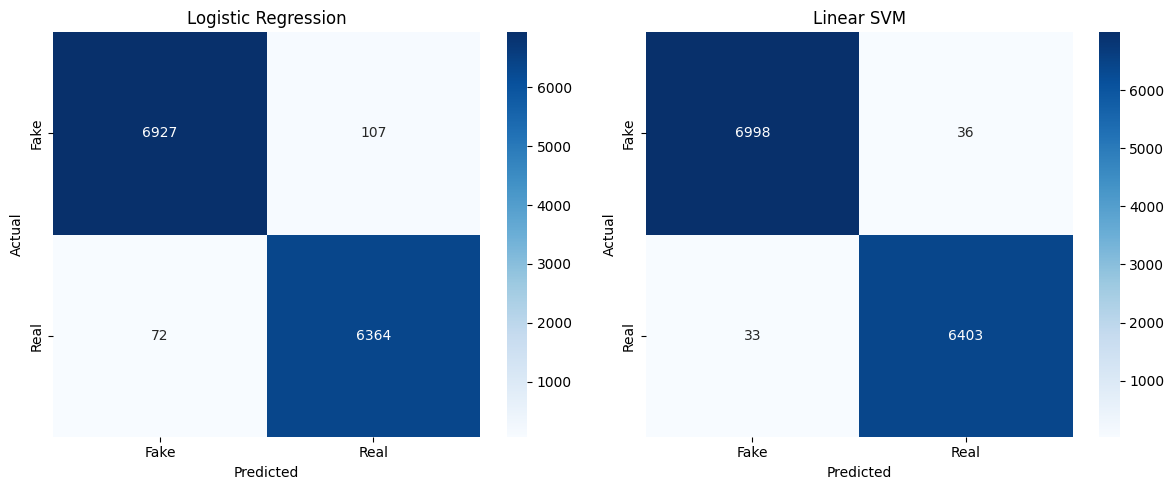

In [156]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, preds) in zip(axes, [("Logistic Regression", pred_lr), ("Linear SVM", pred_svm)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()